In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def target_function(x):
    """目标函数：sin(x) * cos(5x) + 0.3x"""
    return np.sin(x) * np.cos(5 * x) + 0.3 * x

np.random.seed(42)
# 训练集：在[-3, 3]区间随机采样1000个点
x_train = np.random.uniform(-3, 3, 1000).reshape(-1, 1)
y_train = target_function(x_train)

# 测试集：在[-3, 3]区间均匀采样500个点
x_test = np.linspace(-3, 3, 500).reshape(-1, 1)
y_test = target_function(x_test)

In [3]:
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(1,), name='hidden1'),
    keras.layers.Dense(64, activation='relu', name='hidden2'),
    keras.layers.Dense(1, name='output')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
#训练模型
history = model.fit(
    x_train, y_train,
    epochs=200,
    validation_data=(x_test, y_test),
    verbose=0  
)


e:\e_conda\DL-class\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


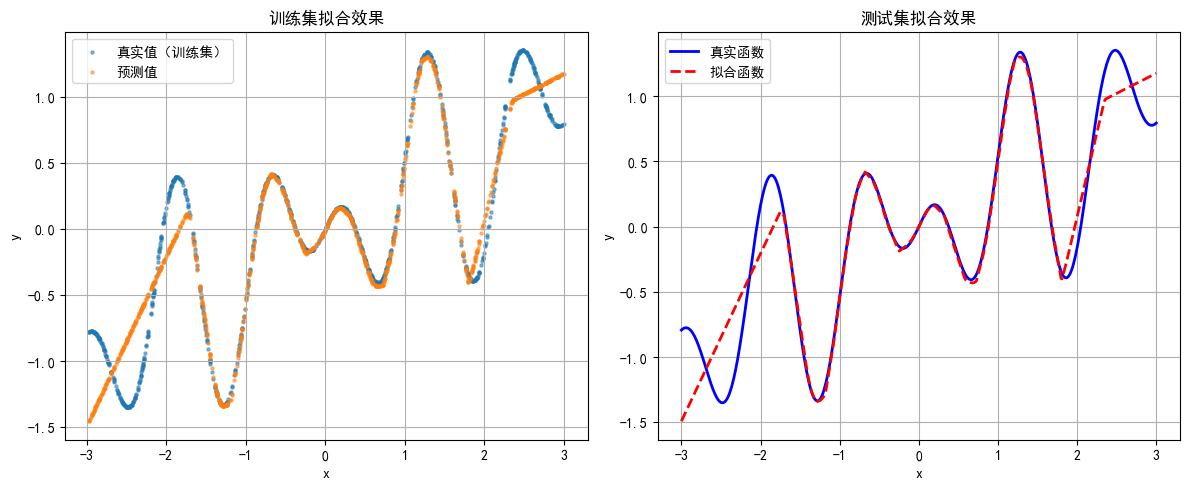

训练集最终MSE: 0.048609
测试集最终MSE: 0.045286


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,061 (51.02 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,708 (34.02 KB)

In [4]:
y_pred_train = model.predict(x_train, verbose=0)
y_pred_test = model.predict(x_test, verbose=0)

plt.figure(figsize=(12, 5))

# 左图：训练集拟合效果
plt.subplot(1, 2, 1)
plt.scatter(x_train, y_train, s=5, alpha=0.5, label='真实值（训练集）')
plt.scatter(x_train, y_pred_train, s=5, alpha=0.5, label='预测值')
plt.xlabel('x')
plt.ylabel('y')
plt.title('训练集拟合效果')
plt.legend()
plt.grid(True)

# 右图：测试集拟合效果
plt.subplot(1, 2, 2)
plt.plot(x_test, y_test, 'b-', linewidth=2, label='真实函数')
plt.plot(x_test, y_pred_test, 'r--', linewidth=2, label='拟合函数')
plt.xlabel('x')
plt.ylabel('y')
plt.title('测试集拟合效果')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('fitting_result.png', dpi=150)
plt.show()


train_loss = model.evaluate(x_train, y_train, verbose=0)
test_loss = model.evaluate(x_test, y_test, verbose=0)
print(f'训练集最终MSE: {train_loss[0]:.6f}')
print(f'测试集最终MSE: {test_loss[0]:.6f}')

model.summary()